# Multi-Dataset Experiment Framework
## Online MROT Anomaly Detection 
This notebook demonstrates how to run experiments across multiple datasets and compare results systematically.

## 1. Import Dependencies

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('./experiments')

from experiment_runner import (
    MultiDatasetExperimentRunner,
    ExperimentConfig
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Configure Datasets

Define all datasets you want to experiment with. Each dataset gets its own configuration.

In [4]:
# List of datasets to process
dataset_configs = [
    ExperimentConfig(
        dataset_path="./datasets/cao2025/S1.csv",
        dataset_name="S1",
        n_train_samples=2000,
        window_size=400,
        n_history=5,
        m_barycenter=3,
        theta_validation=0.80,
        tau_anomaly=0.75,
        K_retrain=5,
        drift_threshold=0.5
    ),
     ExperimentConfig(
         dataset_path="./datasets/cao2025/S2.csv",
         dataset_name="S2",
         n_train_samples=2000,
        window_size=400,
        n_history=5,
        m_barycenter=3,
        theta_validation=0.80,
        tau_anomaly=0.75,
        K_retrain=5,
        drift_threshold=0.5)
]

print(f"Configured {len(dataset_configs)} dataset(s)")

Configured 2 dataset(s)


## 3. Select Methods to Run



In [5]:
# - 'tumbling': Online MROTAD with tumbling window
# - 'sliding': Online MROTAD with sliding window  
# - 'wasserstein': Online Wasserstein (Structured)
# - 'domain_adaptation': Online Domain Adaptation

methods = ['tumbling', 'wasserstein', 'domain_adaptation']


print(f"Selected methods: {methods}")

Selected methods: ['tumbling', 'wasserstein', 'domain_adaptation']


## 4. Initialize Experiment Runner

In [6]:
# Create runner with output directory
runner = MultiDatasetExperimentRunner(output_dir="./results")

print("Experiment runner initialized")
print(f"Results will be saved to: {runner.output_dir}")

Experiment runner initialized
Results will be saved to: results


## 5. Run Experiments

This will run all selected methods on all configured datasets.

In [7]:
%%time
# Run all experiments
runner.run_multiple_datasets(dataset_configs, methods=methods)


STARTING MULTI-DATASET EXPERIMENTS

Dataset: S1
Loading dataset: ./datasets/cao2025/S1.csv
  Running Online MROTAD (Tumbling Window)...
Anomaly scores for initial data computed. AUC Score: 0.9932116996951219
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
 Model retrained successfully!
  Running Online Wasserstein (Structured)...
Anomaly scores for initial data computed. AUC Score: 0.9932116996951219
 PERFORMANCE DRIFT! AUC below threshold: 0.6831
Window 1: AUC=0.6831, Wasserstein=0.0000
 PERFORMANCE DRIFT! AUC below threshold: 0.6803
Window 2: AUC=0.6803, Wasserstein=0.0000
 PERFORMANCE DRIFT! AUC below threshold: 0.7775
Window 3: AUC=0.7775, Wasserstein=0.0000
 PER

## 6. View Summary Results

In [8]:
runner.print_summary()


EXPERIMENT SUMMARY

S1 - MROTAD_Tumbling
  Mean AUC: 0.8172 ± 0.2007
  Drifts Detected: 13
  Execution Time: 3.46s

S1 - Wasserstein_Structured
  Mean AUC: 0.7931 ± 0.1740
  Drifts Detected: 26
  Execution Time: 6.06s

S1 - Domain_Adaptation
  Mean AUC: 0.7567 ± 0.1994
  Drifts Detected: 18
  Execution Time: 2.95s

S2 - MROTAD_Tumbling
  Mean AUC: 0.8001 ± 0.1700
  Drifts Detected: 3
  Execution Time: 1.09s

S2 - Wasserstein_Structured
  Mean AUC: 0.7101 ± 0.2363
  Drifts Detected: 4
  Execution Time: 1.36s

S2 - Domain_Adaptation
  Mean AUC: 0.6461 ± 0.2584
  Drifts Detected: 4
  Execution Time: 1.27s


## 7. Save Results

Save detailed results as JSON and summary as CSV.

In [9]:
# Save results
exp_dir = runner.save_results()



Results saved to: results/experiment_20260205_152112


## 8. Load and Inspect Summary Results

In [10]:
summary_df = pd.read_csv(exp_dir / "summary_results.csv")
display(summary_df)

,Dataset,Method,Mean_AUC,Std_AUC,Num_Drifts,Execution_Time
0,S1,MROTAD_Tumbling,0.817189,0.200736,13,3.460777
1,S1,Wasserstein_Structured,0.793095,0.173978,26,6.064362
2,S1,Domain_Adaptation,0.756749,0.199412,18,2.948296
3,S2,MROTAD_Tumbling,0.800074,0.169971,3,1.093410
4,S2,Wasserstein_Structured,0.710109,0.236260,4,1.360150
5,S2,Domain_Adaptation,0.646060,0.258398,4,1.266571


In [11]:
pivot_auc = summary_df.pivot(index='Dataset', columns='Method', values='Mean_AUC')
print("\nMean AUC Comparison:")
display(pivot_auc)


Mean AUC Comparison:


Method,Domain_Adaptation,MROTAD_Tumbling,Wasserstein_Structured
Dataset,,,
S1,0.756749,0.817189,0.793095
S2,0.646060,0.800074,0.710109


In [12]:
best_methods = summary_df.loc[summary_df.groupby('Dataset')['Mean_AUC'].idxmax()]
print("\nBest Method per Dataset:")
display(best_methods[['Dataset', 'Method', 'Mean_AUC', 'Num_Drifts']])


Best Method per Dataset:


,Dataset,Method,Mean_AUC,Num_Drifts
0,S1,MROTAD_Tumbling,0.817189,13
3,S2,MROTAD_Tumbling,0.800074,3


## 9. Generate Visualizations

IndexError: list index out of range

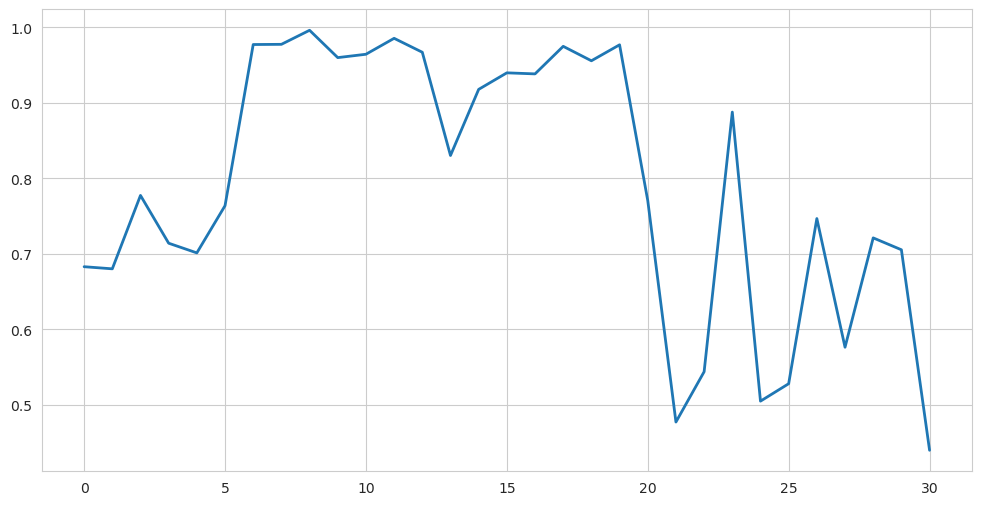

In [13]:
runner.generate_comparison_plots()

print("Plots generated:")
print("  - auc_comparison.png")
print("  - drift_comparison.png")
print("  - execution_time_comparison.png")
print("  - Individual AUC curves for each dataset/method")

## 10. Custom Analysis and Plots

You can create custom visualizations from the results.

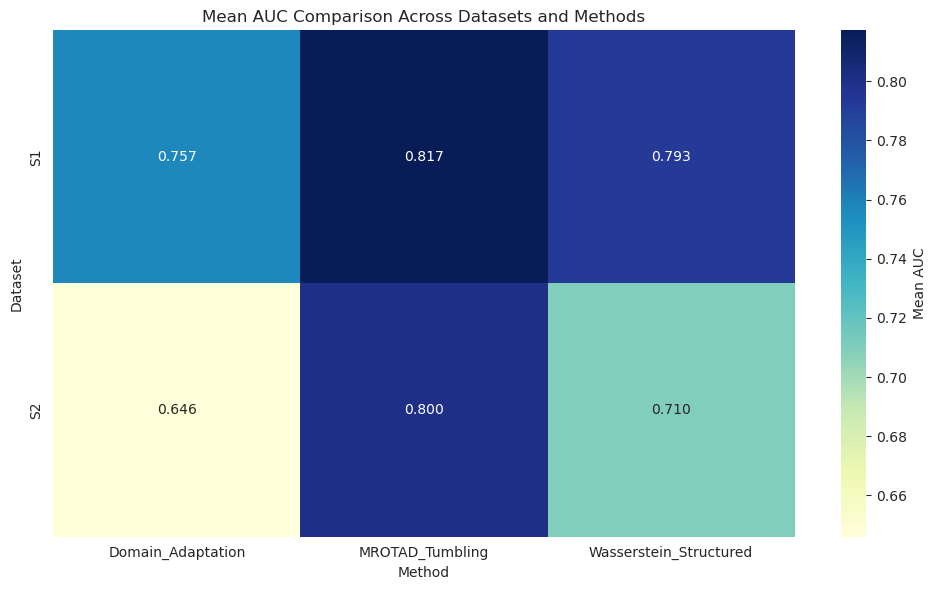

In [ ]:
# Custom plot: AUC comparison heatmap
if len(dataset_configs) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='YlGnBu', 
                cbar_kws={'label': 'Mean AUC'})
    plt.title('Mean AUC Comparison Across Datasets and Methods')
    plt.tight_layout()
    plt.show()

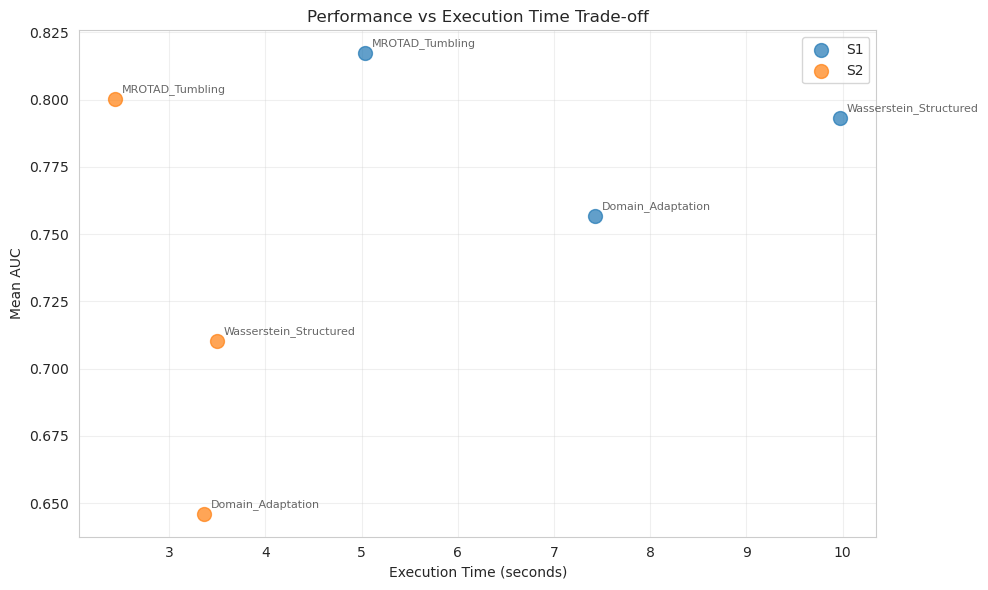

In [ ]:
# Custom plot: Performance vs Execution Time
plt.figure(figsize=(10, 6))
for dataset in summary_df['Dataset'].unique():
    data = summary_df[summary_df['Dataset'] == dataset]
    plt.scatter(data['Execution_Time'], data['Mean_AUC'], 
               s=100, label=dataset, alpha=0.7)
    
    # Add method labels
    for _, row in data.iterrows():
        plt.annotate(row['Method'], 
                    (row['Execution_Time'], row['Mean_AUC']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.7)

plt.xlabel('Execution Time (seconds)')
plt.ylabel('Mean AUC')
plt.title('Performance vs Execution Time Trade-off')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Statistical Analysis

In [ ]:
# Statistical summary by method
print("Statistical Summary by Method:")
print("="*60)
method_stats = summary_df.groupby('Method').agg({
    'Mean_AUC': ['mean', 'std', 'min', 'max'],
    'Num_Drifts': ['mean', 'std'],
    'Execution_Time': ['mean', 'std']
})
display(method_stats)

Statistical Summary by Method:


Mean_AUC                               Num_Drifts  \
                            mean       std       min       max       mean   
Method                                                                      
Domain_Adaptation       0.701405  0.078269  0.646060  0.756749       11.0   
MROTAD_Tumbling         0.808632  0.012103  0.800074  0.817189        8.0   
Wasserstein_Structured  0.751602  0.058679  0.710109  0.793095       15.0   

                                  Execution_Time            
                              std           mean       std  
Method                                                      
Domain_Adaptation        9.899495       5.391839  2.872604  
MROTAD_Tumbling          7.071068       3.736929  1.833714  
Wasserstein_Structured  15.556349       6.734768  4.581124

## 12. Export Results 

In [ ]:
# Create a formatted table for publication
publication_table = summary_df.copy()
publication_table['AUC'] = publication_table.apply(
    lambda x: f"{x['Mean_AUC']:.3f} ± {x['Std_AUC']:.3f}", axis=1
)
publication_table['Time (s)'] = publication_table['Execution_Time'].round(2)

final_table = publication_table[['Dataset', 'Method', 'AUC', 'Num_Drifts', 'Time (s)']]
print("\nPublication-Ready Table:")
display(final_table)

# Save as LaTeX
latex_path = exp_dir / "results_table.tex"
final_table.to_latex(latex_path, index=False)
print(f"\nLaTeX table saved to: {latex_path}")